In [1]:
import os
import sys
from loguru import logger
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

from hippy2d.datasets import ColorectalHistology
from hippy2d.trainer import get_trainer

# Load the broken model
import yaml
config_path = "/home/karella/Projects/rotation-invariant-neural-networks/hippy2d/configs/runs/resnet-learnable/resnet-s1.yaml" 

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

config['d_hparams']['data_dir'] = "/home/karella/Projects/rotation-invariant-neural-networks/hippy2d/data" 



/home/karella/.conda/envs/hippy2d/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
_, model, ds = get_trainer(seed= config['seed'],
                                         epochs=50,
                                         dataset_name=config['dataset_name'],
                                         d_hparams=config['d_hparams'],
                                         model_name=config['model_name'],
                                         m_param=config['m_param'],
                                         optimizer_name=config['optimizer_name'],
                                         optimizer_hparams=config['optimizer_hparams'],
                                         lr_name=config['lr_name'],
                                         lr_hparams=config['lr_hparams'], 
                                         label_smoothing=config.get('label_smoothing', 0.0)) 
ds.prepare_data()
ds.setup(None)

# Model Artifacts
model_path = "/home/karella/Projects/rotation-invariant-neural-networks/hippy2d/hippy2d/xxfl14nc/checkpoints/epoch=0-step=15.ckpt"

best_checkpoint = torch.load(model_path, weights_only=False)
_result = model.load_state_dict(best_checkpoint['state_dict'], strict=False )
print(f"Best model loading from {model_path} : {_result}")
# Data
train_dl = ds.train_dataloader()
val_dl = ds.val_dataloader()
test_dl = ds.test_dataloader()

model.eval()


2025-12-02 11:28:34.197 | DEBUG    | hippy2d.trainer:get_trainer:39 - Default float precision to torch.float32
Seed set to 42
2025-12-02 11:28:34.199 | DEBUG    | hippy2d.trainer:get_trainer:41 - Setting random seed to 42
2025-12-02 11:28:34.240 | DEBUG    | hippy2d.trainer:get_trainer:51 - Using dataset: ColorectalHistology with parameters: {'test_batch_size': 64, 'batch_size': 64, 'normalize': False, 'use_tukey_mask': False, 'data_dir': '/home/karella/Projects/rotation-invariant-neural-networks/hippy2d/data'}
2025-12-02 11:28:34.241 | WARNING  | hippy2d.models:__init__:490 - Stem for ResNet expects masked inputs
2025-12-02 11:28:35.153 | DEBUG    | hippy2d.trainer:get_trainer:53 - Using model: Resnet with parameters: {'in_channels': 3, 'input_size': 150, 'norm': 'batch', 'kernels_size': [11, 11, 11], 'layers': [1, 2, 2], 'channels': [16, 22, 28], 'block_types': ['TimmBasicBlock', 'TimmBasicBlock', 'TimmBasicBlock'], 'layer': 'LearnableCesa', 'num_classes': 8}
Trainer will use only 1 

Best model loading from /home/karella/Projects/rotation-invariant-neural-networks/hippy2d/hippy2d/xxfl14nc/checkpoints/epoch=0-step=15.ckpt : <All keys matched successfully>


InvNet(
  (model): Resnet(
    (stem): Sequential(
      (0): LearnableCesa(
        (moment_layer): MomentLayer(
          (basisexpansion): BlocksBasisExpansion(
            (block_expansion_('irrep_0', 'irrep_1')): SingleBlockBasisExpansion()
            (block_expansion_('irrep_0', 'irrep_4')): SingleBlockBasisExpansion()
            (block_expansion_('irrep_0', 'irrep_0')): SingleBlockBasisExpansion()
            (block_expansion_('irrep_0', 'irrep_3')): SingleBlockBasisExpansion()
            (block_expansion_('irrep_0', 'irrep_2')): SingleBlockBasisExpansion()
          )
        )
        (invariants_layer): InvariantsLayer()
        (conv1x1): Conv2d(39, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      )
      (1): AvgPool2d(kernel_size=2, stride=2, padding=0)
      (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
      (3): ELU(alpha=1.0, inplace=True)
    )
    (layer1): Sequential(
      (0): TimmBasicBlock(
        (conv1): Lear

In [3]:
# Plot train/val/test samples
def plot_samples(dataloader, title, num_samples=5):
    data_iter = next(iter(dataloader))
    if len(data_iter) == 2:
        images, labels = data_iter
    else:
        batch, batch_idx, dl_idx = data_iter
        images, labels = batch
    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        img = images[i].numpy().transpose((1, 2, 0))
        plt.imshow(img)
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

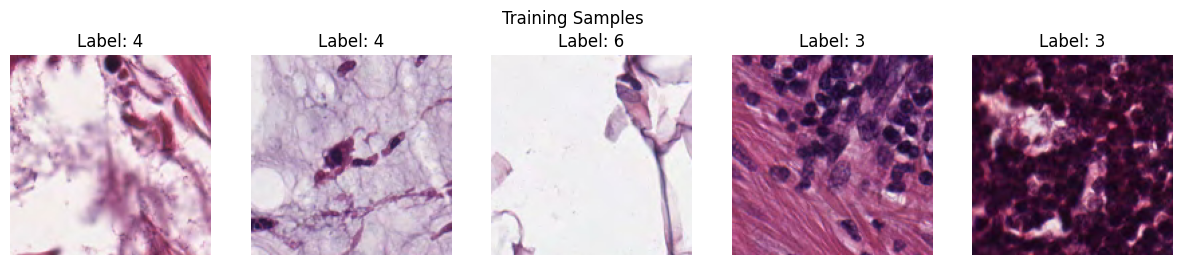

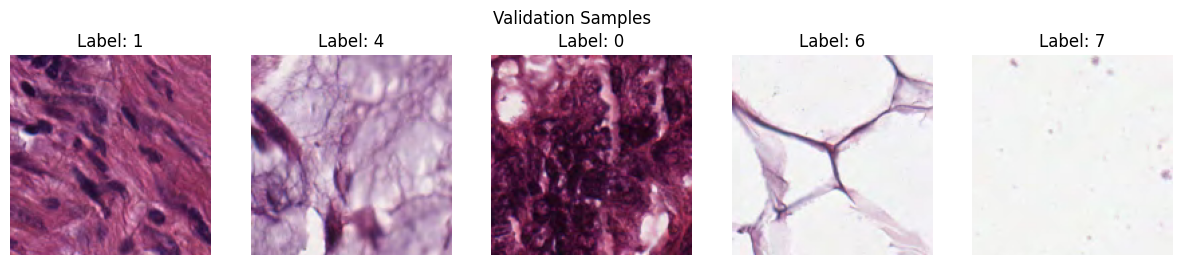

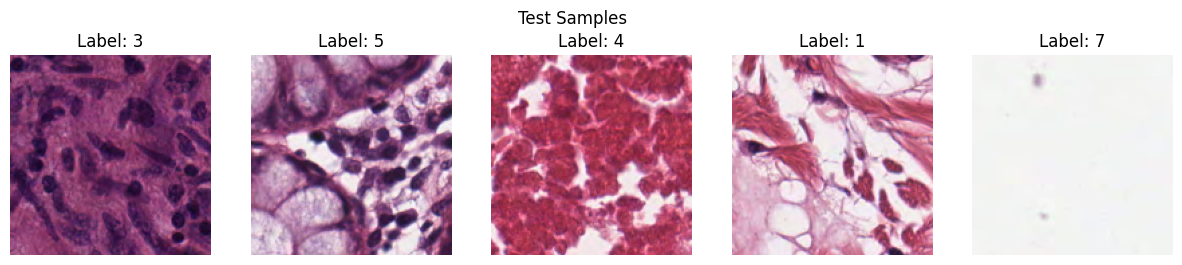

In [4]:
plot_samples(train_dl, "Training Samples")
plot_samples(val_dl, "Validation Samples")
plot_samples(test_dl, "Test Samples")

In [5]:
# Calculate mean and std of training data
def calculate_mean_std(dataloader):
    mean = torch.zeros(3)
    std = torch.zeros(3)
    total_samples = 0
    for data_iter in dataloader:
        if len(data_iter) == 2:
            images, labels = data_iter
        else:
            batch, batch_idx, dl_idx = data_iter
            images, labels = batch
            if dl_idx != 0:
                continue
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_samples += batch_samples
    mean /= total_samples
    std /= total_samples
    return mean.numpy(), std.numpy()

mean, std = calculate_mean_std(train_dl)
print(f"Mean: {mean}, Std: {std} of training data")
val_mean, val_std = calculate_mean_std(val_dl)
print(f"Mean: {val_mean}, Std: {val_std} of validation data")
test_mean, test_std = calculate_mean_std(test_dl)
print(f"Mean: {test_mean}, Std: {test_std} of test data")

Mean: [0.64985883 0.4719596  0.583998  ], Std: [0.14240654 0.14700085 0.12851551] of training data
Mean: [0.6527563 0.4817437 0.5939346], Std: [0.14265393 0.14882986 0.12910986] of validation data
Mean: [0.64736205 0.4659095  0.5780648 ], Std: [0.14006941 0.14166336 0.12465201] of test data


In [6]:
def _forwad_model(x): 
    with torch.no_grad():
        x1 = model.model.stem(x)
        x2 = model.model.layer1(x1)
        x3 = model.model.layer2(x2)
        x4 = model.model.layer3(x3)
        return x1, x2, x3, x4

In [7]:
# Sample train batch 
imgs, _ = next(iter(train_dl))
print("Max, min of input images:", imgs.max(), imgs.min())
print("Mean of batch images:", imgs.mean([0,2,3]))
print("Mean of batch images:", imgs.std([0,2,3]))
x1, x2, x3, x4 = _forwad_model(imgs)
print("After stem:", x1.min(), x1.max(), x1.mean(), x1.std())
print("After layer1:", x2.min(), x2.max(), x2.mean(), x2.std())
print("After layer2:", x3.min(), x3.max(), x3.mean(), x3.std())
print("After layer3", x4.min(), x4.max(), x4.mean(), x4.std())

Max, min of input images: tensor(1.) tensor(0.)
Mean of batch images: tensor([0.6794, 0.4876, 0.5915])
Mean of batch images: tensor([0.2414, 0.3268, 0.2695])
After stem: tensor(-0.9567) tensor(2.5077) tensor(0.0851) tensor(0.5697)
After layer1: tensor(-0.9972) tensor(9.3114) tensor(0.0832) tensor(0.6022)
After layer2: tensor(-0.0257) tensor(0.0318) tensor(0.0024) tensor(0.0165)
After layer3 tensor(-0.0828) tensor(0.0857) tensor(0.0006) tensor(0.0547)


In [11]:
import math 
# Sample train batch 
# log all things higher than 100 in absolute value
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

bad_val_imgs = [] 
bad_val_labels = []

val_dl = ds.val_dataloader()

for idx, (imgs, labels) in enumerate(val_dl):
    imgs = imgs.to(device)
    x1, x2, x3, x4 = _forwad_model(imgs)
    if x1.abs().max() > 100 or x2.abs().max() > 100 or x3.abs().max() > 100 or x4.abs().max() > 100:
        print("Max, min of input images:", imgs.max(), imgs.min())
        print("Mean of batch images:", imgs.mean([0,2,3]))
        print("Mean of batch images:", imgs.std([0,2,3]))
        print("After stem:", x1.min(), x1.max(), x1.mean(), x1.std())
        print("After layer1:", x2.min(), x2.max(), x2.mean(), x2.std())
        print("After layer2:", x3.min(), x3.max(), x3.mean(), x3.std())
        print("After layer3:", x4.min(), x4.max(), x4.mean(), x4.std())
        # Plot samples 
        num_samples = imgs.size(0)
    
        #plt.figure(figsize=(15, 15))
        for i in range(num_samples):

            #plt.subplot(8, 8, i + 1)
            img = imgs[i].cpu().numpy().transpose((1, 2, 0))
            plt.imshow(img)
            # Check which image caused the issue
            max_val = x4[i].abs().max().item()
            if max_val > 100 or math.isnan(max_val):
                bad_val_imgs.append(imgs[i].cpu().numpy())
                bad_val_labels.append(labels[i].cpu().item())
                color = 'red'
            color = 'black'
            #plt.title(f"{max_val:.2e}", color=color)
            #plt.axis('off')
       # plt.suptitle("Validation examples that has exploding layer 4. activation")
       # plt.show()
       # plt.tight_layout()
    

In [9]:
# Same for training

import math 
# Sample train batch 
# log all things higher than 100 in absolute value
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

train_dl = ds.train_dataloader()
train_bad_labels = []
train_bad_imgs  = []

for idx, (imgs, labels) in enumerate(train_dl):
    imgs = imgs.to(device)
    x1, x2, x3, x4 = _forwad_model(imgs)
    if x1.abs().max() > 100 or x2.abs().max() > 100 or x3.abs().max() > 100 or x4.abs().max() > 100:
        print("Max, min of input images:", imgs.max(), imgs.min())
        print("Mean of batch images:", imgs.mean([0,2,3]))
        print("Mean of batch images:", imgs.std([0,2,3]))
        print("After stem:", x1.min(), x1.max(), x1.mean(), x1.std())
        print("After layer1:", x2.min(), x2.max(), x2.mean(), x2.std())
        print("After layer1:", x3.min(), x3.max(), x3.mean(), x3.std())
        print("After layer2:", x4.min(), x4.max(), x4.mean(), x4.std())
        # Plot samples 
        num_samples = imgs.size(0)
        plt.figure(figsize=(15, 15))
        for i in range(num_samples):
            plt.subplot(8, 8, i + 1)
            img = imgs[i].cpu().numpy().transpose((1, 2, 0))
            plt.imshow(img)
            # Check which image caused the issue
            max_val = x4[i].abs().max().item()
            if max_val > 100 or math.isnan(max_val):
                train_bad_imgs.append(imgs[i].cpu().numpy())
                color = 'red'
            color = 'red' if max_val > 100 or math.isnan(max_val) else 'black'
            plt.title(f"{max_val:.2e}", color=color)
            plt.axis('off')
        plt.suptitle("Training examples that has exploding layer 4. activation")
        plt.show()
        plt.tight_layout()


In [10]:
bad_val_imgs = torch.stack([torch.tensor(img) for img in bad_val_imgs])
x1, x2, x3, x4 = _forwad_model(bad_val_imgs.to(device))

# Plot bad validation images
num_bad = bad_val_imgs.size(0)
plt.figure(figsize=(15, 3))
for i in range(num_bad):
    plt.subplot(1, num_bad, i + 1)
    img = bad_val_imgs[i].cpu().numpy().transpose((1, 2, 0))
    plt.imshow(img)
    # Check which image caused the issue
    max_val_1 = x1[i].abs().max().item()
    max_val_2 = x2[i].abs().max().item()
    max_val_3 = x3[i].abs().max().item()
    max_val_4 = x4[i].abs().max().item()
    plt.title(f"Label: {bad_val_labels[i]}\n stem: {max_val_1:.2e} \nlayer1: {max_val_2:.2e} \nlayer3: {max_val_3:.2e} \nlayer4: {max_val_4:.2e}", color='red' if max_val_4 > 100 or math.isnan(max_val_4) else 'black')

RuntimeError: stack expects a non-empty TensorList

In [ ]:
bad_train_imgs = torch.stack([torch.tensor(img) for img in train_bad_imgs])
x1, x2, x3, x4 = _forwad_model(bad_train_imgs.to(device))
# Plot bad training images
num_bad = bad_train_imgs.size(0)
plt.figure(figsize=(15, 15))
for i in range(num_bad):
    plt.subplot(8, 8, i + 1)
    img = bad_train_imgs[i].cpu().numpy().transpose((1, 2, 0))
    plt.imshow(img)
    # Check which image caused the issue
    max_val_1 = x1[i].abs().max().item()
    max_val_2 = x2[i].abs().max().item()
    max_val_3 = x3[i].abs().max().item()
    max_val_4 = x4[i].abs().max().item()
    plt.title(f"Label: {train_bad_labels[i]}")
    #plt.title(f"stem: {max_val_1:.2e} \nlayer1: {max_val_2:.2e} \nlayer3: {max_val_3:.2e} \nlayer4: {max_val_4:.2e}", color='red' if max_val_4 > 100 or math.isnan(max_val_4) else 'black')

    plt.tight_layout()

In [ ]:
# Calculate mean and std of bad images
# Calculate mean and std of training data
mean = torch.zeros(3)
std = torch.zeros(3)
total_samples = 0
images = torch.concat([bad_val_imgs, bad_train_imgs], dim=0)
batch_samples = images.size(0)
images = images.view(batch_samples, images.size(1), -1)
mean += images.mean(2).sum(0)
std += images.std(2).sum(0)
total_samples += batch_samples
mean /= total_samples
std /= total_samples
print(f"Mean: {mean.numpy()}, Std: {std.numpy()} of bad validation images")

In [ ]:

bad_val_imgs = torch.stack([torch.tensor(img) for img in bad_val_imgs])
x1, x2, x3, x4 = _forwad_random_model(bad_val_imgs.to(device))

# Plot bad validation images
num_bad = bad_val_imgs.size(0)
plt.figure(figsize=(15, 3))
for i in range(num_bad):
    plt.subplot(1, num_bad, i + 1)
    img = bad_val_imgs[i].cpu().numpy().transpose((1, 2, 0))
    plt.imshow(img)
    # Check which image caused the issue
    max_val_1 = x1[i].abs().max().item()
    max_val_2 = x2[i].abs().max().item()
    max_val_3 = x3[i].abs().max().item()
    max_val_4 = x4[i].abs().max().item()
    plt.title(f"Label: {bad_val_labels[i]}\n stem: {max_val_1:.2e} \nlayer1: {max_val_2:.2e} \nlayer3: {max_val_3:.2e} \nlayer4: {max_val_4:.2e}", color='red' if max_val_4 > 100 or math.isnan(max_val_4) else 'black')